In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import r2_score
import pandas as pd
import numpy as np

/Users/ilabarymov/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/ilabarymov/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
class Config:
    seed = 42
    test_size = 0.2
    batch_size = 64
    lr = 0.001
    weight_decay = 1e-4
    dropout_rate = 0.3
    patience = 15
    epochs = 200
    
torch.manual_seed(Config.seed)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [3]:
def load_data():
    df = pd.read_csv('encoded_scaled_df.csv', index_col=0)
    df = df.drop(['Unnamed: 0.1', 'Unnamed: 0', 'Sales'], axis=1, errors='ignore')
    
    X = df.drop('Price', axis=1).values
    y = df['Price'].values.reshape(-1, 1)
    
    return X, y

X, y = load_data()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=Config.test_size, random_state=Config.seed
)

def to_tensor(data, device):
    return torch.FloatTensor(data).to(device)

X_train_tensor = to_tensor(X_train, device)
y_train_tensor = to_tensor(y_train, device)
X_test_tensor = to_tensor(X_test, device)
y_test_tensor = to_tensor(y_test, device)

class EnhancedPricePredictor(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(0.1),
            nn.Dropout(0.15),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            
            nn.Linear(32, 1)
        )
        
    def forward(self, x):
        return self.net(x)

input_size = X_train.shape[1]
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = EnhancedPricePredictor(input_size).to(device)
model.load_state_dict(torch.load('price_predictor.pth'))
model.eval()

def evaluate_model():
    model.eval()
    with torch.no_grad():
        test_preds = model(X_test_tensor).cpu().numpy()
        test_true = y_test_tensor.cpu().numpy()
        
        r2 = r2_score(test_true, test_preds)
        
    print(f'\nFinal Metric')
    print(f'R²: {r2:.4f}')

evaluate_model()


Final Metric
R²: 0.8971


/var/folders/pf/dxhtqvm567j60pyv1yzqr_sc0000gn/T/ipykernel_89028/682153786.py:55: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('price_predi


Coordinate Descent 
Iter 1: Улучшение R² = 0.9373
Iter 12: Улучшение R² = 0.9373
Iter 22: Улучшение R² = 0.9373
Iter 23: Улучшение R² = 0.9373
Iter 57: Улучшение R² = 0.9373
Iter 64: Улучшение R² = 0.9373
Iter 96: Улучшение R² = 0.9373
Iter 103: Улучшение R² = 0.9379
Iter 104: Улучшение R² = 0.9379
Iter 107: Улучшение R² = 0.9381
Iter 110: Улучшение R² = 0.9381
Iter 112: Улучшение R² = 0.9383
Iter 123: Улучшение R² = 0.9383
Iter 124: Улучшение R² = 0.9383
Iter 134: Улучшение R² = 0.9383
Iter 147: Улучшение R² = 0.9383
Iter 152: Улучшение R² = 0.9383
Iter 156: Улучшение R² = 0.9383
Iter 172: Улучшение R² = 0.9383
Iter 174: Улучшение R² = 0.9383
Iter 175: Улучшение R² = 0.9384
Iter 181: Улучшение R² = 0.9384
Iter 189: Улучшение R² = 0.9384
Iter 193: Улучшение R² = 0.9384
Iter 198: Улучшение R² = 0.9384
Iter 199: Улучшение R² = 0.9395
Iter 203: Улучшение R² = 0.9397
Iter 221: Улучшение R² = 0.9397
Iter 222: Улучшение R² = 0.9398
Iter 228: Улучшение R² = 0.9398
Iter 231: Улучшение R² = 0.

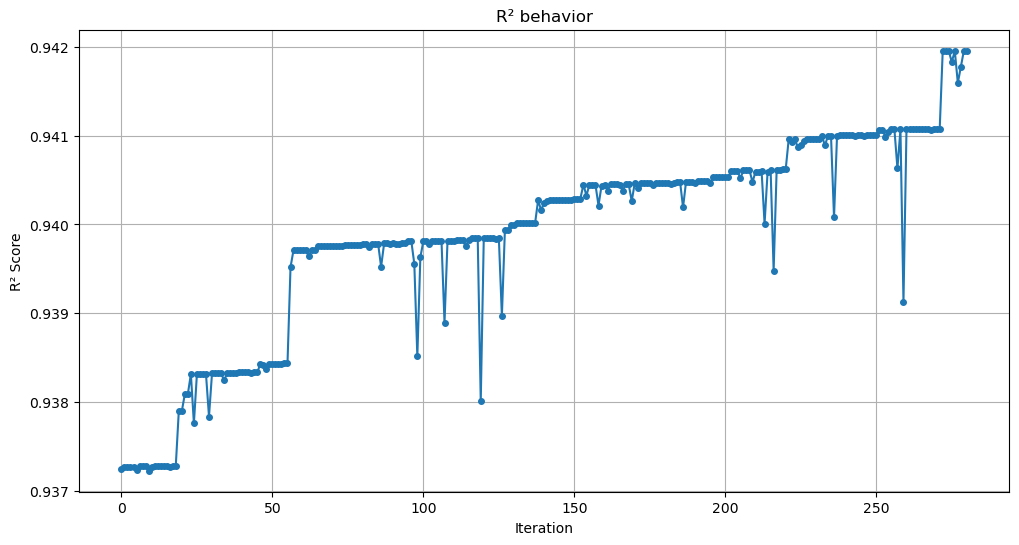


Final Metric
R²: 0.9013


In [4]:
import matplotlib.pyplot as plt

def coordinate_descent_finetune(model, X_val, y_val, sigma=0.05, iterations=500):
    model.eval()
    best_weights = [param.clone().detach() for param in model.parameters()]
    best_r2 = r2_score(y_val.cpu().numpy(), 
                      model(X_val).cpu().detach().numpy())
    
    history_r2 = [best_r2]
    cnt = 0
    for i in range(iterations):
        layer_idx = np.random.randint(len(best_weights))
        param = best_weights[layer_idx]
        
        if len(param.shape) == 1:
            continue
        
        neuron = np.random.randint(param.shape[0])
        weight_idx = np.random.randint(param.shape[1])
        
        original_value = param[neuron, weight_idx].item()
        
        noise = torch.randn(1).item() * sigma
        new_value = original_value + noise
        
        new_weights = [p.clone().detach() for p in best_weights]
        new_weights[layer_idx][neuron, weight_idx] = new_value
        
        with torch.no_grad():
            for param, new_param in zip(model.parameters(), new_weights):
                param.copy_(new_param)
        
        with torch.no_grad():
            y_pred = model(X_val).cpu().numpy()
            current_r2 = r2_score(y_val.cpu().numpy(), y_pred)
        
        history_r2.append(current_r2)
        
        if current_r2 > best_r2:
            best_r2 = current_r2
            best_weights = new_weights
            print(f"Iter {i+1}: Улучшение R² = {best_r2:.4f}")
        else:
            new_weights[layer_idx][neuron, weight_idx] = original_value

    with torch.no_grad():
        for param, best_param in zip(model.parameters(), best_weights):
            param.copy_(best_param)
    
    return best_r2, history_r2


print("\nCoordinate Descent ")
final_r2, history_r2 = coordinate_descent_finetune(
    model,
    X_train_tensor,
    y_train_tensor,
    sigma=0.01,
    iterations=1000
)

print(f"\nFinal R² : {final_r2:.4f}")

plt.figure(figsize=(12, 6))
plt.plot(range(len(history_r2)), history_r2, marker='o', linestyle='-', markersize=4)
plt.title('R² behavior')
plt.xlabel('Iteration')
plt.ylabel('R² Score')
plt.grid(True)
plt.show()

evaluate_model()